In [ ]:
!pip install -q kagglehub

In [ ]:
import kagglehub

path = kagglehub.dataset_download("yusufmurtaza01/chest-xray-pneumonia-balanced-dataset")

print("Dataset path:", path)

100%|██████████| 1.66G/1.66G [00:17<00:00, 103MB/s] 

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/yusufmurtaza01/chest-xray-pneumonia-balanced-dataset/versions/1


In [ ]:
import os
print("Folders inside dataset:")
print(os.listdir(path))

Folders inside dataset:
['test', 'val', 'train']


In [ ]:
for root, dirs, files in os.walk(path):
    print(root)
    break

/root/.cache/kagglehub/datasets/yusufmurtaza01/chest-xray-pneumonia-balanced-dataset/versions/1


In [ ]:
for root, dirs, files in os.walk(path):
    for d in dirs:
        print(os.path.join(root, d))
    break

/root/.cache/kagglehub/datasets/yusufmurtaza01/chest-xray-pneumonia-balanced-dataset/versions/1/test
/root/.cache/kagglehub/datasets/yusufmurtaza01/chest-xray-pneumonia-balanced-dataset/versions/1/val
/root/.cache/kagglehub/datasets/yusufmurtaza01/chest-xray-pneumonia-balanced-dataset/versions/1/train


In [ ]:
train_dir = path + "/train"
val_dir   = path + "/val"
test_dir  = path + "/test"

print(train_dir)
print(val_dir)
print(test_dir)

/root/.cache/kagglehub/datasets/yusufmurtaza01/chest-xray-pneumonia-balanced-dataset/versions/1/train
/root/.cache/kagglehub/datasets/yusufmurtaza01/chest-xray-pneumonia-balanced-dataset/versions/1/val
/root/.cache/kagglehub/datasets/yusufmurtaza01/chest-xray-pneumonia-balanced-dataset/versions/1/test


In [ ]:
import shutil
shutil.copytree(path, "/content/dataset")

'/content/dataset'

In [ ]:
train_dir = "/content/dataset/train"
val_dir   = "/content/dataset/val"
test_dir  = "/content/dataset/test"

In [ ]:
!pip install -q scikit-learn

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import numpy as np
from sklearn.utils.class_weight import compute_class_weight


train_dir = "/content/dataset/train"
val_dir   = "/content/dataset/val"
test_dir  = "/content/dataset/test"

IMG_SIZE = 224
BATCH_SIZE = 16

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=5,
    zoom_range=0.05,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_data = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_data = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_data.classes),
    y=train_data.classes
)
class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)

base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3)
]

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=callbacks,
    class_weight=class_weights
)

loss, acc = model.evaluate(test_data)
print("Test Accuracy:", acc)

from sklearn.metrics import classification_report, confusion_matrix

preds = model.predict(test_data)
y_pred = (preds > 0.6).astype(int)

print(classification_report(test_data.classes, y_pred))
print(confusion_matrix(test_data.classes, y_pred))

model.save("/content/efficientnet_pneumonia_simple.h5")

Found 6800 images belonging to 2 classes.
Found 1700 images belonging to 2 classes.
Found 30 images belonging to 2 classes.
Class Weights: {0: np.float64(1.0), 1: np.float64(1.0)}
Epoch 1/15
425/425 ━━━━━━━━━━━━━━━━━━━━ 189s 389ms/step - accuracy: 0.8635 - loss: 0.3204 - val_accuracy: 0.9494 - val_loss: 0.1500 - learning_rate: 1.0000e-04
Epoch 2/15
425/425 ━━━━━━━━━━━━━━━━━━━━ 155s 364ms/step - accuracy: 0.9196 - loss: 0.1981 - val_accuracy: 0.9588 - val_loss: 0.1174 - learning_rate: 1.0000e-04
Epoch 3/15
425/425 ━━━━━━━━━━━━━━━━━━━━ 154s 363ms/step - accuracy: 0.9360 - loss: 0.1606 - val_accuracy: 0.9571 - val_loss: 0.1113 - learning_rate: 1.0000e-04
Epoch 4/15
425/425 ━━━━━━━━━━━━━━━━━━━━ 156s 366ms/step - accuracy: 0.9397 - loss: 0.1524 - val_accuracy: 0.9582 - val_loss: 0.1021 - learning_rate: 1.0000e-04
Epoch 5/15
425/425 ━━━━━━━━━━━━━━━━━━━━ 155s 365ms/step - accuracy: 0.9453 - loss: 0.1388 - val_accuracy: 0.9624 - val_loss: 0.0954 - learning_rate: 1.0000e-04
Epoch 6/15
425/425 ━

              precision    recall  f1-score   support

           0       1.00      0.87      0.93        15
           1       0.88      1.00      0.94        15

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30

[[13  2]
 [ 0 15]]


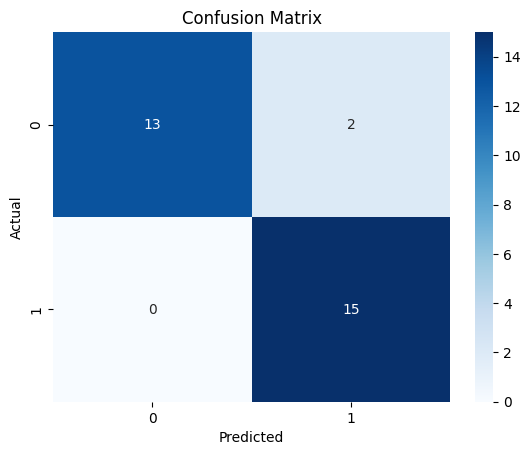

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


cm = confusion_matrix(test_data.classes, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
